In [1]:
import torch
from torch.utils.data import DataLoader

from shapenet_dataset import ShapeNetDataset
from visualize import plot_pointclouds, visualize_reconstructions

# autoreload py
%load_ext autoreload
%autoreload 2

# 5000 points

Using dataset: pc5000 (./sampled_poincloud_5000/)
Number of shapes: 6778
Points per shape: 5000


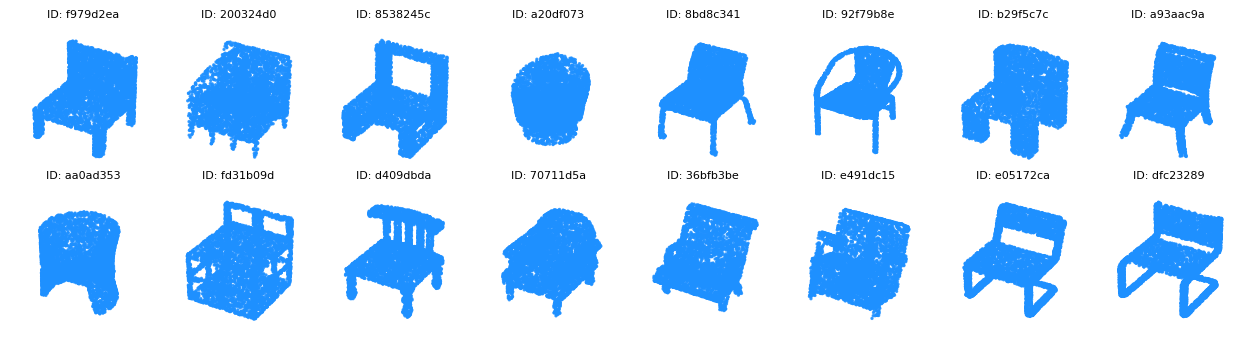

In [2]:
# Pick the dataset variant you want to train on.
# Supported: "pc5000" -> ./sampled_poincloud_5000/, "pc10000" -> ./sampled_poincloud_10000/
dataset_key = "pc5000"

data_roots = {
    "pc5000": "./sampled_poincloud_5000/",
    "pc10000": "./sampled_poincloud_10000/",
}

dataset = ShapeNetDataset(data_dir=data_roots[dataset_key], object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Using dataset: {dataset_key} ({data_roots[dataset_key]})")
print(f"Number of shapes: {len(dataset)}")
print(f"Points per shape: {dataset[0]['points'].shape[0]}")

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list, n_cols=8)
    break

In [3]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from model.base_model import PointCloudAE
from pytorch3d.loss import chamfer_distance
import numpy as np

from experiment_runner import ExperimentConfig, run_training

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42

# Adjust batch size for higher point counts to reduce OOM risk.
batch_size_by_dataset = {
    "pc5000": 8,
    "pc10000": 4,
}
batch_size = batch_size_by_dataset[dataset_key]

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

print(f"Batch size for {dataset_key}: {batch_size}")
print(f"Training points per shape: {num_points}")

/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


device: cuda
Batch size for pc5000: 8
Training points per shape: 5000


Selecting diverse interpolation anchors:   0%|          | 0/678 [00:00<?, ?it/s]

Selecting diverse interpolation anchors:   0%|          | 0/678 [00:00<?, ?it/s]

Selecting diverse interpolation anchors:   0%|          | 0/678 [00:00<?, ?it/s]

Selected val_set local indices: [60, 439, 310, 592]
Selected dataset indices: [3289, 1670, 4959, 3904]
Selected object_ids: ['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


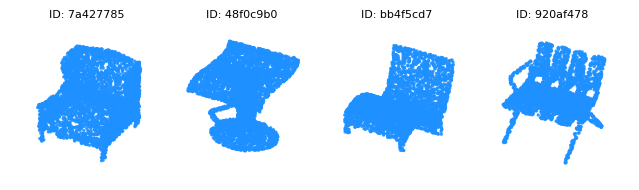

Created diverse_val_loader with 4 FPS-selected chairs.


In [4]:
# Select 4 maximally diverse validation chairs using shared helper
from utils.interpolation_anchors import build_diverse_anchor_loader

diverse_val_loader, diverse_local_idx, diverse_ids = build_diverse_anchor_loader(
    source_loader=val_loader,
    n_select=4,
    seed=seed,
    compute_device=device,
    show_progress=True,
)

# Map local val_set indices back to original dataset indices
diverse_dataset_idx = [int(val_idx[i]) for i in diverse_local_idx]

print("Selected val_set local indices:", diverse_local_idx)
print("Selected dataset indices:", diverse_dataset_idx)
print("Selected object_ids:", diverse_ids)

# Visual sanity check: these are the 4 anchors for hard interpolation.
anchor_batch = next(iter(diverse_val_loader))
diverse_pc_list = list(zip(anchor_batch["object_id"], anchor_batch["points"]))
plot_pointclouds(diverse_pc_list, n_cols=4)

print("Created diverse_val_loader with 4 FPS-selected chairs.")

In [5]:
import wandb
# wandb.login(key="")

In [6]:
# 1) Baseline experiment: Chamfer Distance only
model_cd = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_cd = torch.optim.Adam(model_cd.parameters(), lr=lr)
loss_fn_cd = lambda recon, points: chamfer_distance(
    recon.float(),
    points.float(),
    batch_reduction="mean",
    point_reduction="mean",
)[0]

cfg_cd = ExperimentConfig(
    name=f"baseline_cd_{num_points}pts",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="/ist-nas/ist-share/vision/pratchp/shapevae_weights/",
    epoch_log_every=10,
)

run_dir_cd, summary_cd = run_training(
    config=cfg_cd,
    model=model_cd,
    optimizer=optimizer_cd,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)
print("Baseline CD run dir:", run_dir_cd)
print("Baseline CD summary:", summary_cd)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pratch/.netrc.
wandb: Currently logged in as: alephnir (alephnir-vistec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[baseline_cd_5000pts] interpolation anchors selected: idx=[60, 439, 310, 592], ids=['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


train:baseline_cd_5000pts:   0%|          | 0/84800 [00:00<?, ?it/s]

[baseline_cd_5000pts] epoch 10/100 train 0.002579 val 0.002752 best 0.002747
[baseline_cd_5000pts] epoch 20/100 train 0.001951 val 0.002284 best 0.002200
[baseline_cd_5000pts] epoch 30/100 train 0.001701 val 0.002016 best 0.002016
[baseline_cd_5000pts] epoch 40/100 train 0.001554 val 0.002010 best 0.001960
[baseline_cd_5000pts] epoch 50/100 train 0.001478 val 0.001968 best 0.001953
[baseline_cd_5000pts] epoch 60/100 train 0.001472 val 0.001978 best 0.001898
[baseline_cd_5000pts] epoch 70/100 train 0.001413 val 0.001893 best 0.001856
[baseline_cd_5000pts] epoch 80/100 train 0.001359 val 0.001855 best 0.001849
[baseline_cd_5000pts] epoch 90/100 train 0.001347 val 0.001942 best 0.001849
[baseline_cd_5000pts] epoch 100/100 train 0.001319 val 0.001857 best 0.001842


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
train/loss,█▆▅▄▃▃▃▃▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/best,█▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▅▄▄▃▃▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,95
best_val,0.00184
epoch,100
run_dir,/ist-nas/ist-share/v...
train/loss,0.00132
val/best,0.00184
val/loss,0.00186


Baseline CD run dir: /ist-nas/ist-share/vision/pratchp/shapevae_weights/20260427-011943_pratch_baseline_cd_5000pts
Baseline CD summary: {'best_val': 0.0018422278849517598, 'best_epoch': 95}


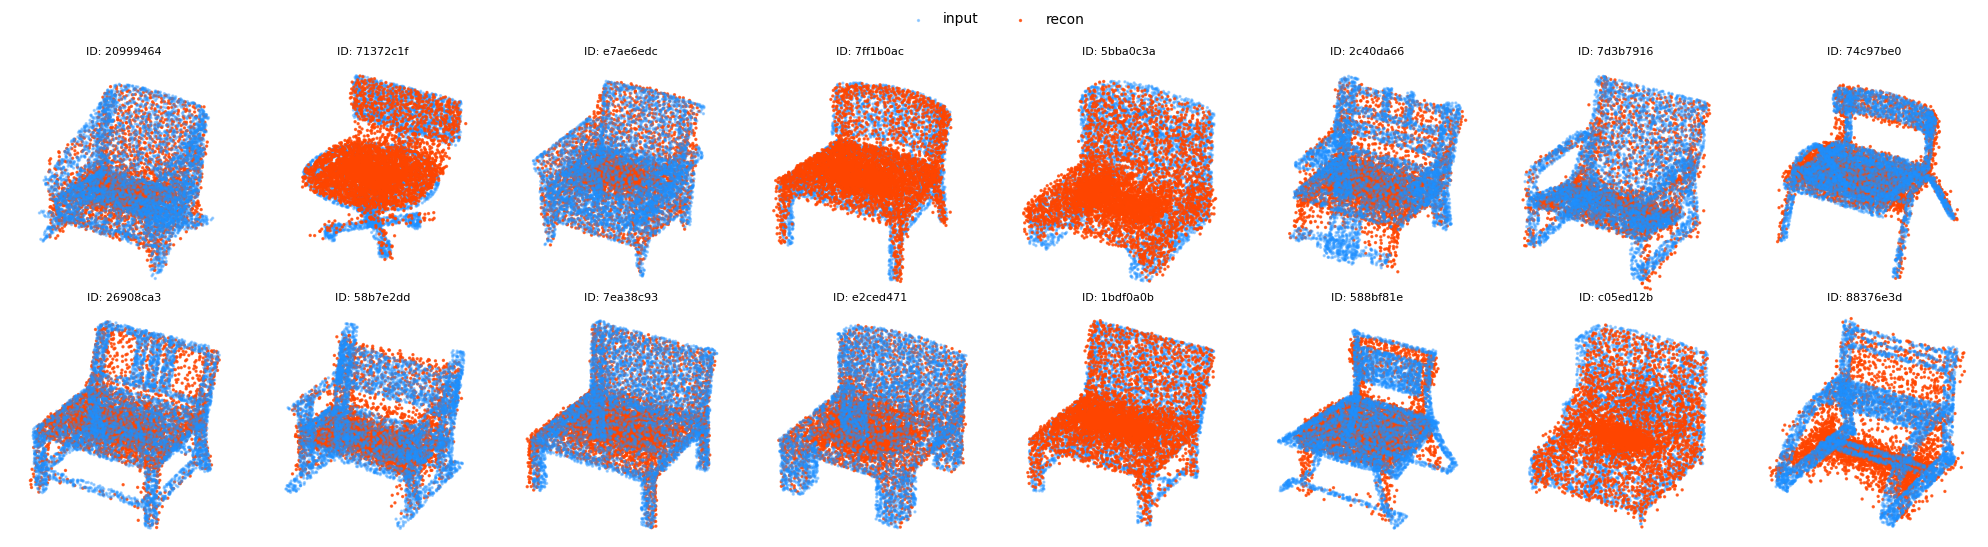

In [7]:
# Visualize baseline reconstructions across N validation batches
visualize_reconstructions(
    model=model_cd,
    loader=val_loader,
    device=device,
    num_batches=2,
    n_cols=8,
)

# 10000 points

Using dataset: pc5000 (./sampled_poincloud_5000/)
Number of shapes: 6778
Points per shape: 5000


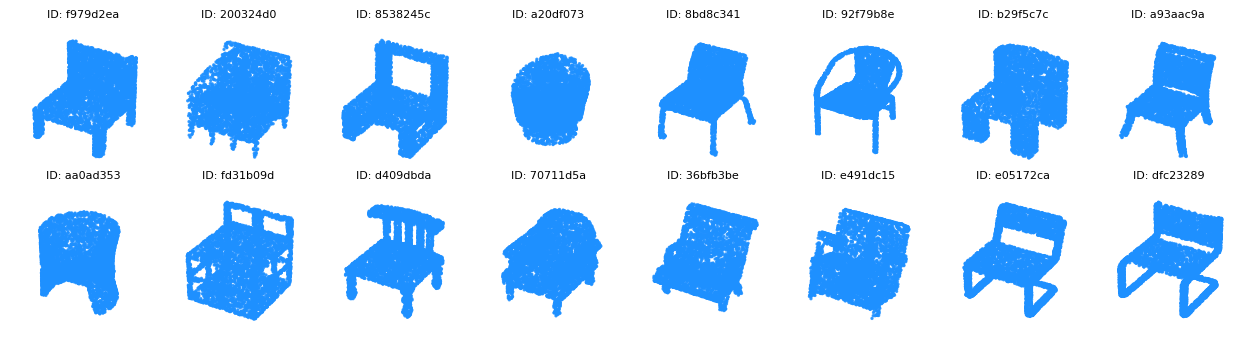

In [ ]:
# Pick the dataset variant you want to train on.
# Supported: "pc5000" -> ./sampled_poincloud_5000/, "pc10000" -> ./sampled_poincloud_10000/
dataset_key = "pc10000"

data_roots = {
    "pc5000": "./sampled_poincloud_5000/",
    "pc10000": "./sampled_poincloud_10000/",
}

dataset = ShapeNetDataset(data_dir=data_roots[dataset_key], object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Using dataset: {dataset_key} ({data_roots[dataset_key]})")
print(f"Number of shapes: {len(dataset)}")
print(f"Points per shape: {dataset[0]['points'].shape[0]}")

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list, n_cols=8)
    break

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from model.base_model import PointCloudAE
from pytorch3d.loss import chamfer_distance
import numpy as np

from experiment_runner import ExperimentConfig, run_training

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42

# Adjust batch size for higher point counts to reduce OOM risk.
batch_size_by_dataset = {
    "pc5000": 8,
    "pc10000": 4,
}
batch_size = batch_size_by_dataset[dataset_key]

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

print(f"Batch size for {dataset_key}: {batch_size}")
print(f"Training points per shape: {num_points}")

/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


device: cuda
Batch size for pc5000: 8
Training points per shape: 5000


Selecting diverse interpolation anchors:   0%|          | 0/678 [00:00<?, ?it/s]

Selecting diverse interpolation anchors:   0%|          | 0/678 [00:00<?, ?it/s]

Selecting diverse interpolation anchors:   0%|          | 0/678 [00:00<?, ?it/s]

Selected val_set local indices: [60, 439, 310, 592]
Selected dataset indices: [3289, 1670, 4959, 3904]
Selected object_ids: ['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


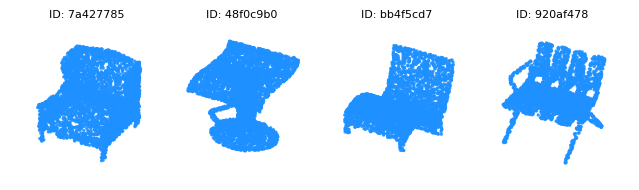

Created diverse_val_loader with 4 FPS-selected chairs.


In [ ]:
# Select 4 maximally diverse validation chairs using shared helper
from utils.interpolation_anchors import build_diverse_anchor_loader

diverse_val_loader, diverse_local_idx, diverse_ids = build_diverse_anchor_loader(
    source_loader=val_loader,
    n_select=4,
    seed=seed,
    compute_device=device,
    show_progress=True,
)

# Map local val_set indices back to original dataset indices
diverse_dataset_idx = [int(val_idx[i]) for i in diverse_local_idx]

print("Selected val_set local indices:", diverse_local_idx)
print("Selected dataset indices:", diverse_dataset_idx)
print("Selected object_ids:", diverse_ids)

# Visual sanity check: these are the 4 anchors for hard interpolation.
anchor_batch = next(iter(diverse_val_loader))
diverse_pc_list = list(zip(anchor_batch["object_id"], anchor_batch["points"]))
plot_pointclouds(diverse_pc_list, n_cols=4)

print("Created diverse_val_loader with 4 FPS-selected chairs.")

In [ ]:
import wandb
# wandb.login(key="")

In [ ]:
# 1) Baseline experiment: Chamfer Distance only
model_cd = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_cd = torch.optim.Adam(model_cd.parameters(), lr=lr)
loss_fn_cd = lambda recon, points: chamfer_distance(
    recon.float(),
    points.float(),
    batch_reduction="mean",
    point_reduction="mean",
)[0]

cfg_cd = ExperimentConfig(
    name=f"baseline_cd_{num_points}pts",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="/ist-nas/ist-share/vision/pratchp/shapevae_weights/",
    epoch_log_every=10,
)

run_dir_cd, summary_cd = run_training(
    config=cfg_cd,
    model=model_cd,
    optimizer=optimizer_cd,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)
print("Baseline CD run dir:", run_dir_cd)
print("Baseline CD summary:", summary_cd)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pratch/.netrc.
wandb: Currently logged in as: alephnir (alephnir-vistec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[baseline_cd_5000pts] interpolation anchors selected: idx=[60, 439, 310, 592], ids=['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


train:baseline_cd_5000pts:   0%|          | 0/84800 [00:00<?, ?it/s]

[baseline_cd_5000pts] epoch 10/100 train 0.002579 val 0.002752 best 0.002747
[baseline_cd_5000pts] epoch 20/100 train 0.001951 val 0.002284 best 0.002200
[baseline_cd_5000pts] epoch 30/100 train 0.001701 val 0.002016 best 0.002016
[baseline_cd_5000pts] epoch 40/100 train 0.001554 val 0.002010 best 0.001960
[baseline_cd_5000pts] epoch 50/100 train 0.001478 val 0.001968 best 0.001953
[baseline_cd_5000pts] epoch 60/100 train 0.001472 val 0.001978 best 0.001898
[baseline_cd_5000pts] epoch 70/100 train 0.001413 val 0.001893 best 0.001856
[baseline_cd_5000pts] epoch 80/100 train 0.001359 val 0.001855 best 0.001849
[baseline_cd_5000pts] epoch 90/100 train 0.001347 val 0.001942 best 0.001849
[baseline_cd_5000pts] epoch 100/100 train 0.001319 val 0.001857 best 0.001842


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
train/loss,█▆▅▄▃▃▃▃▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/best,█▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▅▄▄▃▃▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,95
best_val,0.00184
epoch,100
run_dir,/ist-nas/ist-share/v...
train/loss,0.00132
val/best,0.00184
val/loss,0.00186


Baseline CD run dir: /ist-nas/ist-share/vision/pratchp/shapevae_weights/20260427-011943_pratch_baseline_cd_5000pts
Baseline CD summary: {'best_val': 0.0018422278849517598, 'best_epoch': 95}


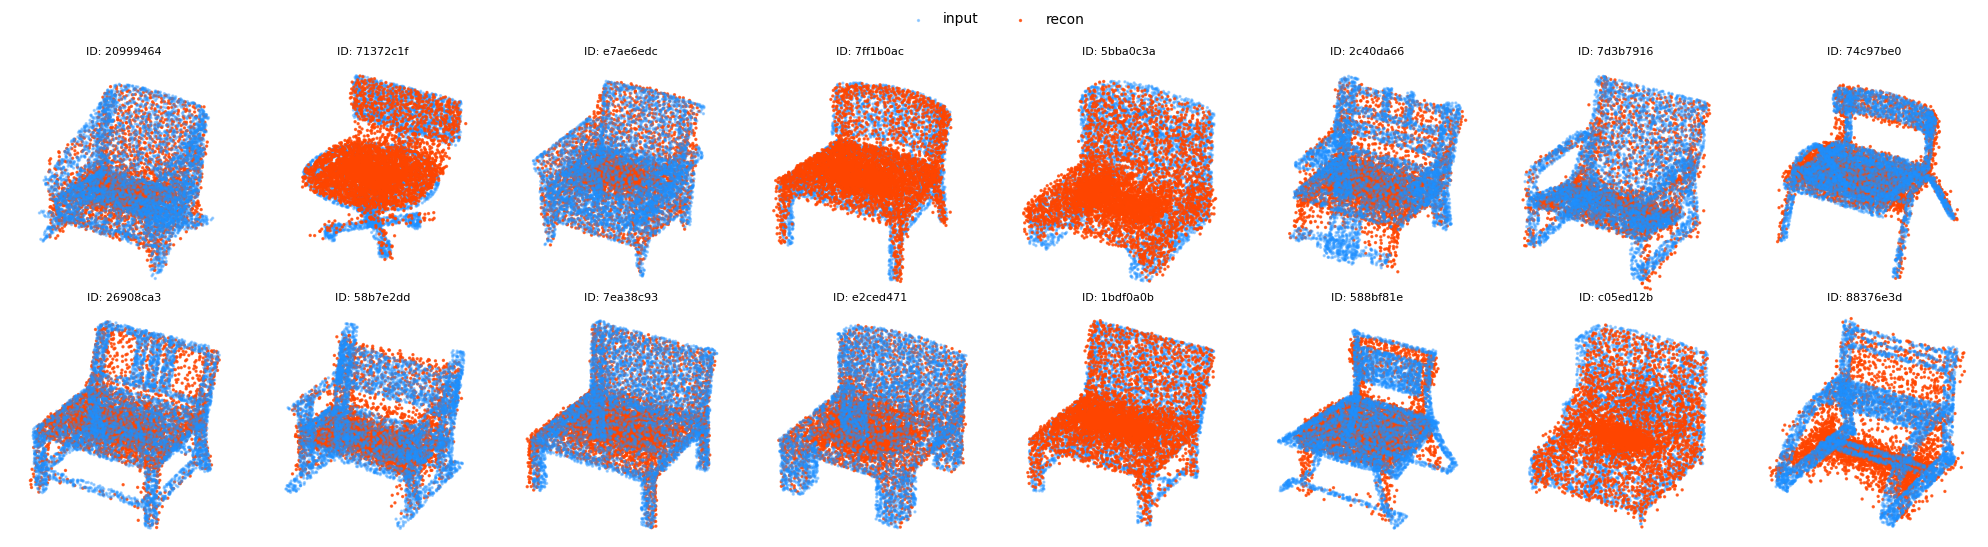

In [ ]:
# Visualize baseline reconstructions across N validation batches
visualize_reconstructions(
    model=model_cd,
    loader=val_loader,
    device=device,
    num_batches=2,
    n_cols=8,
)